In [1]:
import pandas as pd
import numpy as np
import requests
from statsmodels.tsa.stattools import coint
import matplotlib.pyplot as plt
import time

In [2]:
FEE_RATE = 0.001
CAPITAL = 1_000 # $1000 per side, $2000 per trade

In [3]:
def get_historical_data(symbol, interval='60', num_candles=3000):
    # docs: https://bybit-exchange.github.io/docs/v5/market/kline
    url = 'https://api.bybit.com/v5/market/kline'
    all_data = []
    end = int(time.time() * 1000)

    while len(all_data) < num_candles:
        params = {
            'category': 'spot',
            'symbol': symbol,
            'interval': interval,
            'limit': 1000,
            'end': end
        }
        r = requests.get(url, params=params)
        data = r.json()['result']['list']
        if not data:
            break
        all_data.extend(data)
        end = int(data[-1][0]) - 1
        time.sleep(0.01)

    df = pd.DataFrame(all_data, columns=[
        'timestamp', 'open', 'high', 'low', 'close', 'volume', 'turnover'
    ])
    df['timestamp'] = pd.to_datetime(df['timestamp'].astype(float), unit='ms')
    df['close'] = df['close'].astype(float)
    df = df[['timestamp', 'close']].sort_values('timestamp').reset_index(drop=True)
    return df.iloc[:num_candles]

def backtest(price_a, price_b, zscore, capital=CAPITAL, fee_rate=FEE_RATE):
    position = 0
    pnl = 0
    pnl_history = []

    for i in range(1, len(zscore)):
        if position == 0 and zscore[i] > 2:
            position = -1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == 0 and zscore[i] < -2:
            position = 1
            entry_price_a = price_a[i]
            entry_price_b = price_b[i]
        elif position == -1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (entry_price_a - price_a[i])
            pnl += units_b * (price_b[i] - entry_price_b)
            pnl -= fee_rate * capital * 4
            position = 0
        elif position == 1 and abs(zscore[i]) < 0.5:
            units_a = capital / entry_price_a
            units_b = capital / entry_price_b
            pnl += units_a * (price_a[i] - entry_price_a)
            pnl += units_b * (entry_price_b - price_b[i])
            pnl -= fee_rate * capital * 4
            position = 0

        pnl_history.append(pnl)
    return pnl_history

def analyse_pair(symbol_a, symbol_b, data):
    df_a = data[symbol_a]
    df_b = data[symbol_b]
    price_a = df_a['close'].values
    price_b = df_b['close'].values
    n = min(len(price_a), len(price_b))
    price_a = price_a[:n]
    price_b = price_b[:n]
    timestamps = df_a['timestamp'][:n]
    _, pvalue, _ = coint(price_a, price_b)
    print(f"cointegration p-value: {pvalue:.4f}")

    beta = np.cov(price_a, price_b)[0, 1] / np.var(price_b)
    alpha = np.mean(price_a) - beta * np.mean(price_b)
    spread = price_a - alpha - beta * price_b
    zscore = (spread - spread.mean()) / spread.std()
    pnl_history = backtest(price_a, price_b, zscore, capital=CAPITAL)
    days = int(len(price_a) / 24)
    print(f"total pnl: ${pnl_history[-1]:.2f} over {days} days")
    print(f"daily pnl: ${pnl_history[-1]/days:.2f}/day")

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{symbol_a}|{symbol_b}')

    axes[0, 0].plot(timestamps, price_a / price_a[0], label=symbol_a)
    axes[0, 0].plot(timestamps, price_b / price_b[0], label=symbol_b)
    axes[0, 0].set_title('prices')
    axes[0, 0].legend()
    axes[0, 0].tick_params(axis='x', rotation=45)

    axes[0, 1].plot(timestamps, spread)
    axes[0, 1].set_title('spread')
    axes[0, 1].tick_params(axis='x', rotation=45)

    axes[1, 0].plot(timestamps, zscore)
    axes[1, 0].axhline(2, color='red', linestyle='--', label='short signal')
    axes[1, 0].axhline(-2, color='green', linestyle='--', label='long signal')
    axes[1, 0].axhline(0, color='gray', linestyle=':')
    axes[1, 0].set_title('z-score')
    axes[1, 0].legend()
    axes[1, 0].tick_params(axis='x', rotation=45)

    axes[1, 1].plot(timestamps[1:], pnl_history)
    axes[1, 1].axhline(0, color='gray', linestyle=':')
    axes[1, 1].set_title('cumulative pnl')
    axes[1, 1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

In [4]:
# docs: https://bybit-exchange.github.io/docs/v5/market/tickers
url = 'https://api.bybit.com/v5/market/tickers'
params = {'category': 'spot'}
r = requests.get(url, params=params)
tickers = [ticker['symbol'] for ticker in r.json()['result']['list']]
print(len(tickers))
print(tickers[:50])

598
['SOLBRL', 'ENJUSDT', 'USDYUSDT', 'GODSUSDT', 'XDCUSDT', 'SIGNUSDT', 'SUIUSDT', 'ZKPUSDT', 'ETHRLUSD', 'SKRUSDT', 'WALUSDT', 'ZEREBROUSDT', 'ONDOEUR', 'DYMUSDT', 'BTCAED', 'ROSEUSDT', 'KASUSDC', 'ENAEUR', 'FILUSDC', 'USDTGBP', 'SSVUSDT', 'UNIUSDC', 'DOGEEUR', 'HFTUSDT', 'FTTUSDT', 'FLRUSDT', 'EGLDUSDT', 'USDEUSDT', '1INCHUSDT', 'AEROUSDT', 'AZTECUSDT', 'WLDUSDC', 'STABLEUSDT', 'BRETTUSDT', 'ZRXUSDT', 'PUMPBTCUSDT', 'QTUMUSDT', 'NEONUSDT', 'USDTBUSDT', 'NAVXUSDT', 'TAUSDT', 'METHETH', 'BTCUSDE', 'OPUSDC', 'BTCEUR', 'RENDERUSDT', 'BTTUSDT', 'BLURUSDT', 'ZKUSDC', 'ORDIUSDC']


In [5]:
btc = get_historical_data('BTCUSDT')
eth = get_historical_data('ETHUSDT')
sol = get_historical_data('SOLUSDT')
btc.head()

,timestamp,close
0,2026-02-28 15:00:00,64838.8
1,2026-02-28 16:00:00,65094.8
2,2026-02-28 17:00:00,65439.6
3,2026-02-28 18:00:00,65909.6
4,2026-02-28 19:00:00,66346.9


In [6]:
data = {
    'BTC': btc,
    'ETH': eth,
    'SOL': sol,
}
major = ['BTC', 'ETH', 'SOL']

for i, a in enumerate(major):
    for j, b in enumerate(major):
        if j > i:
            _, pvalue, _ = coint(data[a]['close'], data[b]['close'])
            print(f"{a}|{b}: {pvalue:.4f}")

BTC|ETH: 0.7517
BTC|SOL: 0.9256
ETH|SOL: 0.8830


In [7]:
tickers_usdt = [t for t in tickers if t.endswith('USDT')]
print(len(tickers_usdt))
print(tickers_usdt[:50])

431
['ENJUSDT', 'USDYUSDT', 'GODSUSDT', 'XDCUSDT', 'SIGNUSDT', 'SUIUSDT', 'ZKPUSDT', 'SKRUSDT', 'WALUSDT', 'ZEREBROUSDT', 'DYMUSDT', 'ROSEUSDT', 'SSVUSDT', 'HFTUSDT', 'FTTUSDT', 'FLRUSDT', 'EGLDUSDT', 'USDEUSDT', '1INCHUSDT', 'AEROUSDT', 'AZTECUSDT', 'STABLEUSDT', 'BRETTUSDT', 'ZRXUSDT', 'PUMPBTCUSDT', 'QTUMUSDT', 'NEONUSDT', 'USDTBUSDT', 'NAVXUSDT', 'TAUSDT', 'RENDERUSDT', 'BTTUSDT', 'BLURUSDT', 'PONKEUSDT', 'KMNOUSDT', 'KSMUSDT', 'FORTUSDT', 'WBTCUSDT', 'MOVEUSDT', 'PYBOBOUSDT', 'RECALLUSDT', 'KASUSDT', 'MANTRAUSDT', 'NSUSDT', 'OPGUSDT', 'JUVUSDT', 'TUSDUSDT', 'WAVESUSDT', 'RUNEUSDT', 'LMWRUSDT']


In [8]:
# inspect ticker fields, turnover24h used for liquidity filter
print(r.json()['result']['list'][0])

{'symbol': 'SOLBRL', 'bid1Price': '427', 'bid1Size': '26.7973', 'ask1Price': '433', 'ask1Size': '0.5823', 'lastPrice': '429', 'prevPrice24h': '426.2', 'price24hPcnt': '0.0066', 'highPrice24h': '430.4', 'lowPrice24h': '420.4', 'turnover24h': '415545.34593', 'volume24h': '977.5173'}


In [9]:
tickers_filt = [t_info['symbol'] for t_info in r.json()['result']['list']
                if float(t_info['turnover24h']) > 1_000_000
                and t_info['symbol'].endswith('USDT')]
print(len(tickers_filt))
print(tickers_filt[:50])

91
['SUIUSDT', 'ZKPUSDT', 'USDEUSDT', 'AEROUSDT', 'RENDERUSDT', 'HYPEUSDT', 'BILLUSDT', 'PUMPUSDT', 'PENGUUSDT', 'DOTUSDT', 'ADAUSDT', 'HOODXUSDT', 'MONUSDT', 'GRAMUSDT', 'BSBUSDT', 'LITUSDT', 'MPLXUSDT', 'BTCUSDT', 'SOLUSDT', 'L3USDT', 'ZBTUSDT', 'NEARUSDT', 'WIFUSDT', 'GRASSUSDT', 'ENAUSDT', 'ARBUSDT', 'WLDUSDT', 'BASEDUSDT', 'SEIUSDT', 'ONDOUSDT', 'NOMUSDT', 'BCHUSDT', 'SHIBUSDT', 'XPLUSDT', 'COINXUSDT', 'HBARUSDT', 'TSLAXUSDT', 'NIGHTUSDT', 'XLMUSDT', 'PEPEUSDT', 'FFUSDT', 'DEEPUSDT', 'USDCUSDT', 'CAPUSDT', 'MANAUSDT', 'TIAUSDT', 'METUSDT', 'ARXUSDT', 'HUSDT', 'CCUSDT']


In [10]:
data_filt = {}
for ticker in tickers_filt:
    data_filt[ticker] = get_historical_data(ticker)

results = []
for i, a in enumerate(tickers_filt):
    for j, b in enumerate(tickers_filt):
        if j > i:
            n = min(len(data_filt[a]), len(data_filt[b]))
            _, pvalue, _ = coint(data_filt[a]['close'].iloc[:n], data_filt[b]['close'].iloc[:n])
            results.append([a, b, pvalue])

results_df = pd.DataFrame(results, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_df[results_df['pvalue'] < 0.01].sort_values('pvalue')
print(strong.head(20))

       ticker_a   ticker_b        pvalue
3342  TAIKOUSDT   BIRBUSDT  4.637047e-09
3348  TAIKOUSDT   AVAXUSDT  6.305241e-09
3335  TAIKOUSDT    LTCUSDT  1.022280e-08
3346  TAIKOUSDT   AAVEUSDT  1.407556e-08
3323  TAIKOUSDT     ZKUSDT  1.491324e-08
3326  TAIKOUSDT    XRPUSDT  2.020654e-08
3352  TAIKOUSDT    ZROUSDT  2.414110e-08
3353  TAIKOUSDT  STETHUSDT  2.859238e-08
3322  TAIKOUSDT    ETHUSDT  2.935163e-08
3316  TAIKOUSDT   BONKUSDT  3.507642e-08
3336  TAIKOUSDT  TRUMPUSDT  4.008263e-08
3333  TAIKOUSDT  ETHFIUSDT  4.229990e-08
3321  TAIKOUSDT      SUSDT  4.959077e-08
3320  TAIKOUSDT    UNIUSDT  5.023539e-08
3327  TAIKOUSDT    JTOUSDT  6.997276e-08
3318  TAIKOUSDT     IPUSDT  8.044562e-08
3338  TAIKOUSDT    POLUSDT  8.330360e-08
3317  TAIKOUSDT   XAUTUSDT  1.164421e-07
3340  TAIKOUSDT    MNTUSDT  1.268104e-07
3328  TAIKOUSDT   USD1USDT  1.496549e-07


In [11]:
print(len(strong))
print(strong.to_string())

188
       ticker_a     ticker_b        pvalue
3342  TAIKOUSDT     BIRBUSDT  4.637047e-09
3348  TAIKOUSDT     AVAXUSDT  6.305241e-09
3335  TAIKOUSDT      LTCUSDT  1.022280e-08
3346  TAIKOUSDT     AAVEUSDT  1.407556e-08
3323  TAIKOUSDT       ZKUSDT  1.491324e-08
3326  TAIKOUSDT      XRPUSDT  2.020654e-08
3352  TAIKOUSDT      ZROUSDT  2.414110e-08
3353  TAIKOUSDT    STETHUSDT  2.859238e-08
3322  TAIKOUSDT      ETHUSDT  2.935163e-08
3316  TAIKOUSDT     BONKUSDT  3.507642e-08
3336  TAIKOUSDT    TRUMPUSDT  4.008263e-08
3333  TAIKOUSDT    ETHFIUSDT  4.229990e-08
3321  TAIKOUSDT        SUSDT  4.959077e-08
3320  TAIKOUSDT      UNIUSDT  5.023539e-08
3327  TAIKOUSDT      JTOUSDT  6.997276e-08
3318  TAIKOUSDT       IPUSDT  8.044562e-08
3338  TAIKOUSDT      POLUSDT  8.330360e-08
3317  TAIKOUSDT     XAUTUSDT  1.164421e-07
3340  TAIKOUSDT      MNTUSDT  1.268104e-07
3328  TAIKOUSDT     USD1USDT  1.496549e-07
3315  TAIKOUSDT     LINKUSDT  1.563528e-07
3331  TAIKOUSDT    ASTERUSDT  1.716629e-07
3334  T

In [12]:
tickers_liquid = [t_info['symbol'] for t_info in r.json()['result']['list']
               if float(t_info['turnover24h']) > 10_000_000
               and t_info['symbol'].endswith('USDT')]
print(len(tickers_liquid))
print(tickers_liquid)

10
['HYPEUSDT', 'LITUSDT', 'BTCUSDT', 'SOLUSDT', 'XPLUSDT', 'USDCUSDT', 'ARXUSDT', 'ETHUSDT', 'XRPUSDT', 'SLXUSDT']


In [13]:
data_liquid = {}
for ticker in tickers_liquid:
    data_liquid[ticker] = get_historical_data(ticker)

results_liquid = []
for i, a in enumerate(tickers_liquid):
    for j, b in enumerate(tickers_liquid):
        if j > i:
            n = min(len(data_liquid[a]), len(data_liquid[b]))
            _, pvalue, _ = coint(data_liquid[a]['close'].iloc[:n], data_liquid[b]['close'].iloc[:n])
            results_liquid.append([a, b, pvalue])

results_liquid_df = pd.DataFrame(results_liquid, columns=['ticker_a', 'ticker_b', 'pvalue'])
strong = results_liquid_df[results_liquid_df['pvalue'] < 0.05]
print(len(strong))
print(strong.to_string())

1
   ticker_a ticker_b    pvalue
15  LITUSDT  XRPUSDT  0.049047


LITUSDT|XRPUSDT
cointegration p-value: 0.0490
total pnl: $493.98 over 125 days
daily pnl: $3.95/day


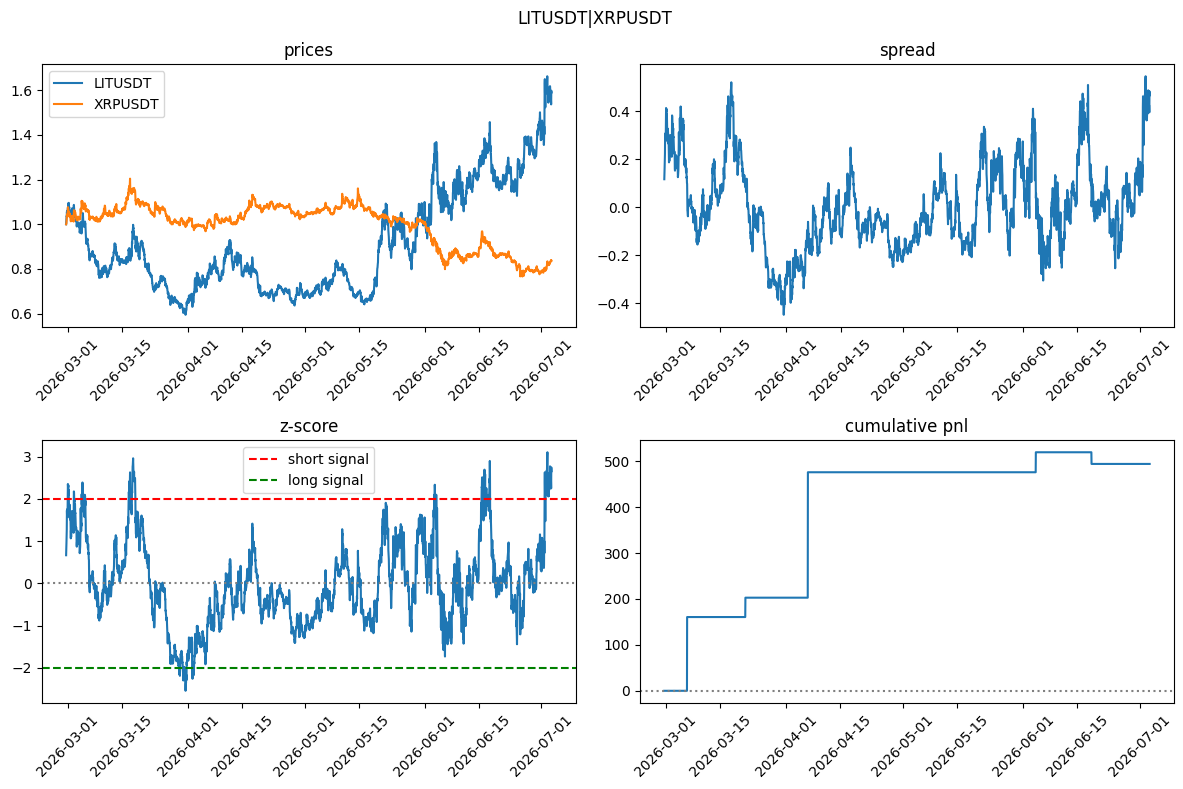

In [14]:
for ticker_a, ticker_b in zip(strong['ticker_a'], strong['ticker_b']):
    print(f"{ticker_a}|{ticker_b}")
    analyse_pair(ticker_a, ticker_b, data_liquid)